In [1]:
import pathlib
import random

import matplotlib.pyplot as plt
import numpy as np

import tensorflow as tf
import xarray as xr

from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import backend as K

2024-08-15 13:58:02.714400: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-15 13:58:02.902741: I tensorflow/core/util/port.cc:104] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tfrecord_dir = pathlib.Path('/gpfs/work2/0/prjs1027/tfrecords/run2')
output_variables = ["hs", "theta0_x", "theta0_y", "tmm10", "tps", "hswe"]
input_variables = ["xwnd", "ywnd", "ssh", "xcur", "ycur"]
boundary_variables = ["hs_bnd", "hswe_bnd", "tmm10_bnd"]
variable_fields = input_variables + output_variables + boundary_variables

min_max_values = xr.open_dataset(tfrecord_dir / "min-max-values/min-max-values.nc")

for bnd_var in boundary_variables:
    min_max_values[bnd_var] = min_max_values[bnd_var.split("_")[0]]

min_max_values["theta0_x"] = xr.DataArray(np.array([0, 1.]), dims='index')
min_max_values["theta0_y"] = xr.DataArray(np.array([0, 1.]), dims='index')

In [3]:
learning_rate = 1e-4
n_epochs = 100
batch_size = 16
steps_per_execution = 1

model_version = "swan_ens_nn_v0003"

src_dir = pathlib.Path().resolve().parent
model_dir = src_dir / f"trained_models/{model_version}"
model_dir.mkdir(exist_ok=True, parents=True)

raster_shape = (481, 421, 2)
widths = [16, 32, 64, 128, 256, 256]
block_depth = 3

In [4]:
def get_files(data_path):
    files = tf.io.gfile.glob(data_path + "/" + "*.tfrecords")
    return files


def get_dataset(files):
    """return a tfrecord dataset with all tfrecord files"""
    dataset = tf.data.TFRecordDataset(files)
    dataset = dataset.map(tf_parse)
    return dataset


def tf_parse(eg, variable_fields=variable_fields):
    """parse an example (or batch of examples, not quite sure...)"""

    # here we re-specify our format
    # you can also infer the format from the data using tf.train.Example.FromString
    # but that did not work
    parse_dict = {
        "height": tf.io.FixedLenFeature([], tf.int64),
        "width": tf.io.FixedLenFeature([], tf.int64),
        "depth": tf.io.FixedLenFeature([], tf.int64),
    }

    vars = variable_fields
    for var in vars:
        parse_dict[var] = tf.io.FixedLenFeature([], tf.string)

    example = tf.io.parse_example(
        eg[tf.newaxis],
        parse_dict,
    )

    variables = {}
    for var in variable_fields:
        variables[var] = tf.io.parse_tensor(example[var][0], out_type="float32")
        variables[var] = (variables[var] - min_max_values[var].values[0]) / (
            min_max_values[var].values[1] - min_max_values[var].values[0]
        )
        variables[var] = tf.where(
            tf.math.is_nan(variables[var]),
            tf.zeros_like(variables[var]) - 9,
            variables[var],
        )
        if var in output_variables:
            variables[var] = variables[var][..., -1]
            variables[var] = tf.reshape(variables[var], (481, 421, 1))

    variables["hs_bnd"] = tf.reshape(variables["hs_bnd"], (22, 1))
    variables["tmm10_bnd"] = tf.reshape(variables["tmm10_bnd"], (22, 1))
    variables["hswe_bnd"] = tf.reshape(variables["hswe_bnd"], (22, 1))

    image_inputs = tf.concat([variables[var] for var in input_variables], axis=-1)
    boundary_inputs = tf.concat(
        [variables["hs_bnd"], variables["tmm10_bnd"], variables["hswe_bnd"]], axis=-1
    )

    inputs = (image_inputs, boundary_inputs)
    outputs = tf.concat([variables[var] for var in output_variables], axis=-1)

    return inputs, outputs

In [5]:
# Get dataset and shuffle
random.seed(0)
files = get_files(str(tfrecord_dir))
random.shuffle(files)
files = files[-10:]
dataset = get_dataset(files)
# Filter out all samples with high values
# dataset = dataset.filter(lambda x, y: tf.reduce_all(x <= 1))
# dataset = dataset.filter(lambda x, y: tf.reduce_all(y <= 10))

train_dataset = (
    dataset.shuffle(buffer_size=1000, seed=0, reshuffle_each_iteration=False)
    .take(int(0.7 * len(files) * 10))
    .batch(batch_size, drop_remainder=True)
)
test_dataset = (
    dataset.shuffle(buffer_size=1000, seed=0, reshuffle_each_iteration=False)
    .skip(int(0.7 * len(files) * 10))
    .batch(batch_size, drop_remainder=True)
)

2024-08-15 13:58:27.295395: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX512_VNNI
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-08-15 13:58:27.702087: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1613] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 18209 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB MIG 3g.20gb, pci bus id: 0000:ca:00.0, compute capability: 8.0


In [6]:
model = tf.keras.models.load_model(model_dir / (model_version + '.h5'))

1/1 [==============================] - 0s 59ms/step
(16, 481, 421, 1)


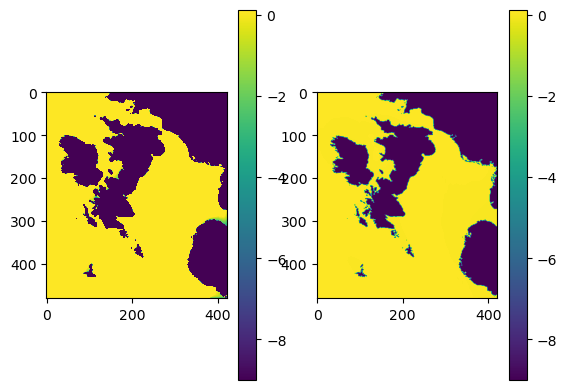

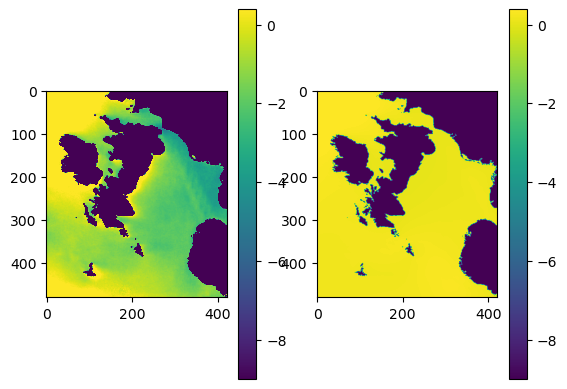

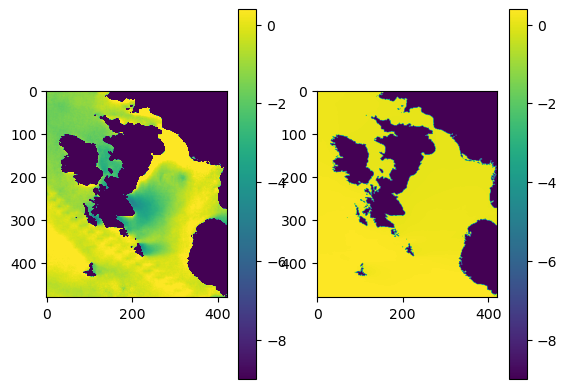

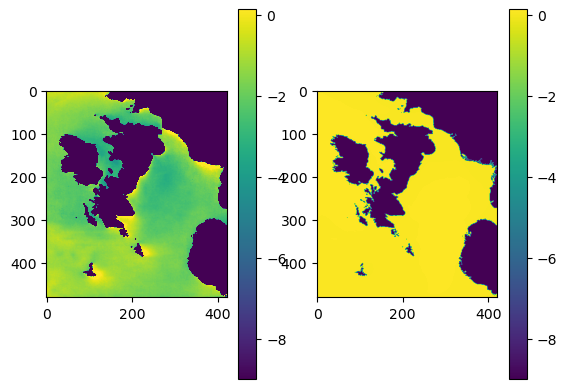

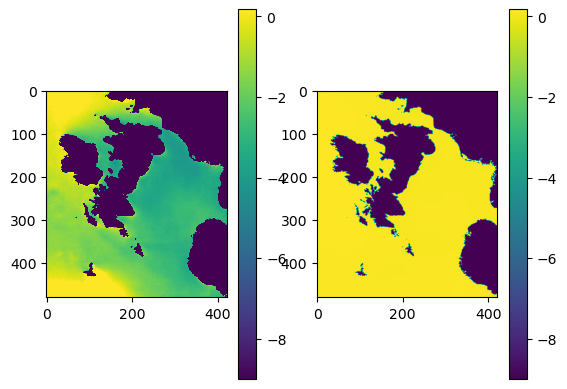

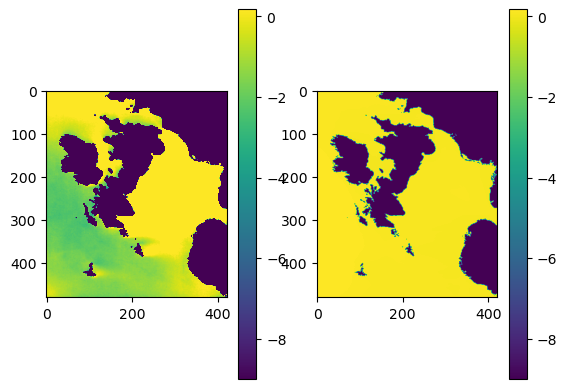

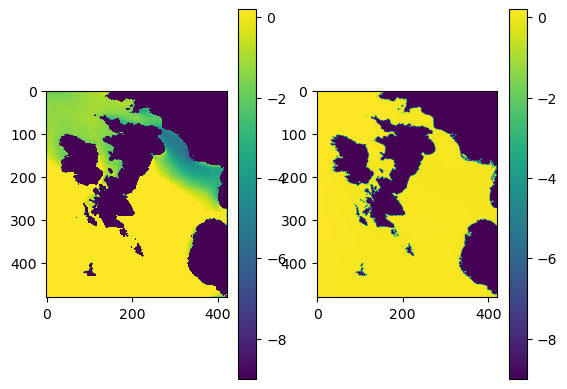

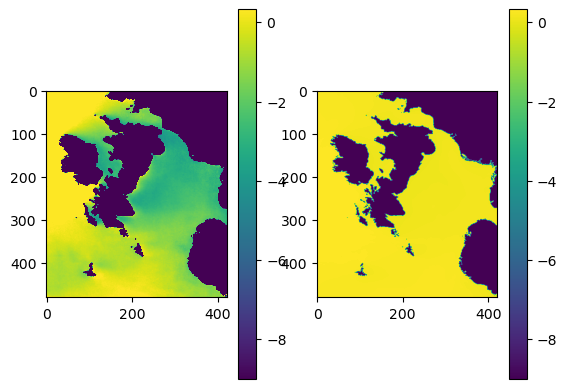

In [13]:
for i, o in test_dataset.take(1):
    o_pred = model.predict(i)
    # o_pred = o_pred.numpy()
    print(o_pred.shape)
    for j, var in enumerate([output_variables[0]]):
        o_pred[..., j] = (min_max_values[var].values[1] - min_max_values[var].values[0]) * o_pred[..., j] + min_max_values[var].values[0]
        for k in range(8):
            fig, axes = plt.subplots(ncols=2)
            vmin, vmax = np.percentile(o[k, ..., j], (5, 95))
            im_pred = axes[0].imshow(o_pred[k, ..., j], vmin=vmin, vmax=vmax)
            im_truth = axes[1].imshow(o[k, ..., j], vmin=vmin, vmax=vmax)
            plt.colorbar(im_pred)
            plt.colorbar(im_truth)